# MSR X-Ray — Mining Software Repositories **(by release)**

**A quality & testing X-ray of a local git project.**

This notebook mirrors the [TestMiner](https://andrehora.github.io/testminer/) methodology (Overview · Test Location · Test History · Test Dependencies) and extends it with code-quality and security signals.

**Pipeline:**
1. Repository overview — commits, contributors, churn, language mix
2. Test location & classification — TestMiner's 8 categories (`test`, `e2e`, `mock`, `snapshot`, `fixture`, `benchmark`, `smoke`, `ci-test`) + `production`
3. Test history — evolution across **tags/releases**
4. Test dependencies — declared vs. imported testing libraries
5. Quality signals — `radon` (MI + CC) · `lizard` (complexity) · `bandit` (security)
6. Final X-Ray summary — health score + one-page dashboard

> **Target repo:** `https://github.com/fllsouto/exploring-testing-practices` — but the notebook is repo-agnostic; change `REPO_PATH` below.

## 1. Setup

Install dependencies. Run once; re-runs are no-ops if already installed.

In [ ]:
# DEPRECATED
# Uncomment on first run:
# %pip install --quiet pydriller gitpython pandas matplotlib seaborn radon lizard bandit toml

In [1]:
import os
import re
import json
import subprocess
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pydriller import Repository, Git

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

### Configuration

Set `REPO_PATH` to the local clone of the repository you want to X-ray.
If it doesn't exist, the cell will clone `REPO_URL` there.

In [2]:
# ---- EDIT ME --------------------------------------------------------------

# REPO_URL  = "https://github.com/fllsouto/exploring-testing-practices"
#REPO_PATH = Path("./exploring-testing-practices").resolve()

REPO_URL  = "https://github.com/scrapy/scrapy"
REPO_PATH = Path("./scrapy_repo").resolve()
# ---------------------------------------------------------------------------

if not REPO_PATH.exists():
    print(f"Cloning {REPO_URL} -> {REPO_PATH} ...")
    subprocess.run(["git", "clone", REPO_URL, str(REPO_PATH)], check=True)
else:
    print(f"Using existing repo at {REPO_PATH}")

assert (REPO_PATH / ".git").exists(), f"{REPO_PATH} is not a git repo"
print("OK.")

Cloning https://github.com/scrapy/scrapy -> /home/fllsouto/SpaceSpaces/TheMasteringSpace/disc_isolada_ufmg_s12026_testes_software/exploring-testing-practices/notebooks/scrapy_repo ...


Cloning into '/home/fllsouto/SpaceSpaces/TheMasteringSpace/disc_isolada_ufmg_s12026_testes_software/exploring-testing-practices/notebooks/scrapy_repo'...


OK.


## 2. Repository Overview — by release

Releases (git tags) anchor the analysis instead of individual commits. A single `git log --numstat` pass — with a **live `tqdm` progress bar** — is 10–100× faster than pydriller's per-commit walk, and the resulting commits are grouped into the release they shipped in.

**Outputs:**
- `commits_df` — per-commit metadata (author analysis, top contributors)
- `releases_df` — aggregated per release (commits, churn, contributors, gap)
- `file_churn` / `file_touches` / `churn_df` — per-file accumulators reused by later sections (bubble plot, co-change network)

> If the repo has no tags, this section still produces `commits_df` and the release-level summary is simply empty.

In [ ]:
# Discover releases & total commit count up-front so the next cell can show
# an accurate progress bar. Both are cheap native-git operations.
def list_tags_chronological(repo_path):
    out = subprocess.run(
        ["git", "-C", str(repo_path), "for-each-ref",
         "--sort=creatordate",
         "--format=%(refname:short)\t%(creatordate:iso-strict)",
         "refs/tags"],
        capture_output=True, text=True, check=True,
    ).stdout.strip()
    return [tuple(line.split("\t", 1)) for line in out.splitlines() if "\t" in line]

tags = list_tags_chronological(REPO_PATH)
total_commits = int(subprocess.run(
    ["git", "-C", str(REPO_PATH), "rev-list", "--count", "HEAD"],
    capture_output=True, text=True, check=True,
).stdout.strip() or "0")
print(f"Releases (tags) found : {len(tags)}")
print(f"Commits on HEAD       : {total_commits:,}")


In [ ]:
# Fast native git walker with live progress. Emits the same dataframes
# (commits_df, file_churn, file_touches) as the original pydriller cell but
# typically 10-100x faster because it streams one `git log --numstat` process.
from tqdm.auto import tqdm

SEP  = "\x1e"          # ASCII record separator — unlikely inside a message
HEAD = "#COMMIT#"

def walk_git_log(repo_path):
    """Stream commits from `git log --numstat` as dicts."""
    fmt = f"{HEAD}{SEP}%H{SEP}%an{SEP}%ae{SEP}%aI{SEP}%s"
    cmd = ["git", "-C", str(repo_path), "log",
           "--numstat", f"--pretty=format:{fmt}"]
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, text=True, bufsize=1,
                         errors="replace")
    current = None
    try:
        for line in p.stdout:
            line = line.rstrip("\n")
            if line.startswith(HEAD):
                if current is not None:
                    yield current
                parts = line.split(SEP)
                current = {
                    "hash":   parts[1] if len(parts) > 1 else "",
                    "author": parts[2] if len(parts) > 2 else "",
                    "email":  parts[3] if len(parts) > 3 else "",
                    "date":   parts[4] if len(parts) > 4 else "",
                    "msg":    parts[5] if len(parts) > 5 else "",
                    "files":  [],
                }
            elif line and current is not None:
                parts = line.split("\t")
                if len(parts) == 3:
                    added, deleted, path = parts
                    a = int(added)   if added.isdigit()   else 0
                    d = int(deleted) if deleted.isdigit() else 0
                    current["files"].append((a, d, path))
        if current is not None:
            yield current
    finally:
        p.stdout.close()
        p.wait()

commit_rows  = []
file_churn   = Counter()
file_touches = Counter()

for c in tqdm(walk_git_log(REPO_PATH), total=total_commits or None,
              desc="git log --numstat", unit="commit", smoothing=0.05):
    ins  = sum(a for a, _, _ in c["files"])
    dels = sum(d for _, d, _ in c["files"])
    commit_rows.append({
        "hash":          c["hash"],
        "author":        c["author"],
        "email":         c["email"],
        "date":          c["date"],
        "msg":           c["msg"].splitlines()[0] if c["msg"] else "",
        "files_changed": len(c["files"]),
        "insertions":    ins,
        "deletions":     dels,
    })
    for a, d, path in c["files"]:
        file_churn[path]   += a + d
        file_touches[path] += 1

commits_df = pd.DataFrame(commit_rows)
if not commits_df.empty:
    commits_df["date"] = pd.to_datetime(commits_df["date"], utc=True).dt.tz_convert(None)
    commits_df = commits_df.sort_values("date").reset_index(drop=True)
print(f"Commits analysed: {len(commits_df):,}")
commits_df.head()


In [ ]:
# Release-based overview: assign each commit to the earliest tag with
# tag_date >= commit_date (the release that shipped the commit), then aggregate.
if commits_df.empty:
    releases_df = pd.DataFrame()
    overview    = {"commits": 0, "releases": 0}
elif not tags:
    releases_df = pd.DataFrame()
    overview    = {
        "commits":      len(commits_df),
        "releases":     0,
        "contributors": commits_df["author"].nunique(),
        "age_days":     (commits_df["date"].max() - commits_df["date"].min()).days,
        "total_insertions": int(commits_df["insertions"].sum()),
        "total_deletions":  int(commits_df["deletions"].sum()),
    }
    print("⚠️  No tags found — release grouping is empty; use commits_df instead.")
else:
    tag_df = pd.DataFrame(tags, columns=["tag", "tag_date"])
    tag_df["tag_date"] = pd.to_datetime(tag_df["tag_date"], utc=True).dt.tz_convert(None)
    tag_df = tag_df.sort_values("tag_date").reset_index(drop=True)

    commits_sorted = commits_df.sort_values("date").reset_index(drop=True)
    merged = pd.merge_asof(
        commits_sorted[["date"]],
        tag_df,
        left_on="date", right_on="tag_date",
        direction="forward",
    )
    commits_sorted["release"]  = merged["tag"].fillna("<unreleased>")
    commits_sorted["tag_date"] = merged["tag_date"]
    # Carry per-commit columns needed for the aggregation
    commits_sorted = commits_sorted.join(
        commits_df.set_index("date")[["hash", "author", "files_changed",
                                        "insertions", "deletions"]],
        on="date", how="left", rsuffix="_dup",
    )
    # de-duplicate after the join
    for col in ("hash", "author", "files_changed", "insertions", "deletions"):
        dup = f"{col}_dup"
        if dup in commits_sorted.columns:
            commits_sorted[col] = commits_sorted[col].where(
                commits_sorted[col].notna(), commits_sorted[dup])
            commits_sorted = commits_sorted.drop(columns=[dup])

    releases_df = (commits_sorted.groupby("release", sort=False)
                   .agg(commits=("hash", "count"),
                        contributors=("author", pd.Series.nunique),
                        files_changed=("files_changed", "sum"),
                        insertions=("insertions", "sum"),
                        deletions=("deletions", "sum"),
                        first_commit=("date", "min"),
                        last_commit=("date", "max"),
                        tag_date=("tag_date", "first"))
                   .reset_index()
                   .sort_values("tag_date", na_position="last")
                   .reset_index(drop=True))

    overview = {
        "commits":      len(commits_df),
        "releases":     int((releases_df["release"] != "<unreleased>").sum()),
        "contributors": commits_df["author"].nunique(),
        "first_commit": str(commits_df["date"].min()),
        "last_commit":  str(commits_df["date"].max()),
        "age_days":     (commits_df["date"].max() - commits_df["date"].min()).days,
        "total_insertions": int(commits_df["insertions"].sum()),
        "total_deletions":  int(commits_df["deletions"].sum()),
    }
    display(releases_df)

pd.Series(overview, name="value").to_frame()


In [6]:
top_authors = (commits_df.groupby("author")
               .agg(commits=("hash", "count"),
                    insertions=("insertions", "sum"),
                    deletions=("deletions", "sum"))
               .sort_values("commits", ascending=False))
top_authors.head(15)

,commits,insertions,deletions
author,,,
Pablo Hoffman,2149,923560,479486
Andrey Rakhmatullin,1027,281651,148879
Mikhail Korobov,881,41233,23617
Daniel Graña,764,49866,29431
Adrián Chaves,622,286529,149528
Eugenio Lacuesta,504,87773,44580
Paul Tremberth,503,16322,6596
Daniel Grana,375,121511,33629
Ismael Carnales,250,16704,9684


In [ ]:
# Release cadence: bars = commits per release, line = days between releases.
if releases_df.empty or (releases_df["release"] == "<unreleased>").all():
    print("No releases to plot — add git tags or fall back to commit-level charts on `commits_df`.")
else:
    plotted = releases_df[releases_df["release"] != "<unreleased>"].copy()
    plotted["gap_days"] = plotted["tag_date"].diff().dt.total_seconds() / 86400
    monthly = plotted.set_index("tag_date")["commits"]  # kept for dashboard compatibility

    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    axes[0].bar(plotted["tag_date"], plotted["commits"],
                width=plotted["gap_days"].fillna(7).clip(1, None),
                align="edge", color=sns.color_palette("crest", len(plotted)), alpha=0.85)
    axes[0].set_title("Commits per release")
    axes[0].set_ylabel("commits")

    axes[1].plot(plotted["tag_date"], plotted["gap_days"], marker="o", color="crimson")
    axes[1].set_title("Time between releases (days)")
    axes[1].set_ylabel("days")
    axes[1].set_xlabel("release date")
    plt.tight_layout()
    plt.show()


In [8]:
churn_df = (pd.DataFrame({
                "path":    list(file_churn.keys()),
                "churn":   list(file_churn.values()),
                "touches": [file_touches[p] for p in file_churn.keys()],
            })
            .sort_values("churn", ascending=False)
            .reset_index(drop=True))

print(f"Tracked files with history: {len(churn_df)}")
churn_df.head(15)

Tracked files with history: 2868


,path,churn,touches
0,scrapy/tests/test_contrib_ibl/samples/samples_...,43940,3
1,scrapy/tests/test_contrib_ibl/samples/samples_...,43588,3
2,docs/news.rst,11909,340
3,tests/test_feedexport.py,11503,206
4,sites/scrapy.org/docs/pickle/searchindex.pickle,7444,3
5,scrapy/tests/test_contrib_ibl/samples/samples_...,6206,3
6,docs/topics/settings.rst,5897,328
7,tests/test_downloader_handlers.py,5323,173
8,tests/test_http_request.py,5038,111
9,docs/topics/selectors.rst,5001,99


## 3. Test Location & Classification

Walk the **current working tree** and classify every source file into one of the TestMiner categories, plus `production` and `other`.

**Rules** (evaluated top-down; first match wins):
- `ci-test`    — lives under `.github/workflows/`, `.circleci/`, `.gitlab-ci*`, `azure-pipelines*`, `Jenkinsfile`
- `snapshot`   — path contains `__snapshots__/` or filename ends with `.snap`
- `mock`       — path contains `mocks/`, `__mocks__/`, `stubs/`, or filename matches `*mock*`
- `benchmark`  — path contains `bench/`, `benchmarks/`, or filename matches `bench_*`, `*_bench.*`
- `smoke`      — path contains `smoke/` or filename matches `smoke_*`
- `e2e`        — path contains `e2e/`, `end_to_end/`, `integration/`, `system_test`
- `fixture`    — path contains `fixtures/`, `testdata/`, `test_data/` (conftest.py → `test`)
- `test`       — filename matches `test_*.py`, `*_test.py`, `*.test.*`, `*.spec.*`, or under a `tests/` tree
- `production` — source files (`.py`, `.js`, `.ts`, `.go`, `.java`, `.rb`, ...) that didn't match above
- `other`      — everything else (docs, configs, data, images)

In [9]:
SOURCE_EXTS = {
    ".py", ".js", ".jsx", ".ts", ".tsx", ".go", ".java", ".rb", ".rs",
    ".cs", ".cpp", ".cc", ".c", ".h", ".hpp", ".kt", ".swift", ".php",
    ".scala", ".m", ".mm",
}

CI_DIRS  = (".github/workflows", ".circleci", ".gitlab-ci", "azure-pipelines")
CI_FILES = ("jenkinsfile",)

TEST_FILE_PY    = re.compile(r"^(test_.+|.+_test)\.py$")
TEST_FILE_JS    = re.compile(r".+\.(test|spec)\.(js|jsx|ts|tsx)$")

def classify(path: str) -> str:
    """Classify a repo-relative path into a TestMiner category."""
    p = path.replace("\\", "/").lower()
    name = p.rsplit("/", 1)[-1]
    ext  = "." + name.rsplit(".", 1)[-1] if "." in name else ""

    # ci-test
    if any(d in p for d in CI_DIRS) or name in CI_FILES:
        return "ci-test"
    if p.startswith(".gitlab-ci") or name.startswith("azure-pipelines"):
        return "ci-test"

    # snapshot
    if "__snapshots__/" in p or ext == ".snap":
        return "snapshot"

    # mock
    if "/mocks/" in p or "/__mocks__/" in p or "/stubs/" in p or "mock" in name:
        return "mock"

    # benchmark
    if "/bench/" in p or "/benchmarks/" in p or name.startswith("bench_") or "_bench." in name:
        return "benchmark"

    # smoke
    if "/smoke/" in p or name.startswith("smoke_") or "_smoke." in name:
        return "smoke"

    # e2e / integration
    if "/e2e/" in p or "/end_to_end/" in p or "/integration/" in p or "system_test" in p:
        return "e2e"

    # fixture (conftest is test, not fixture)
    if name.startswith("conftest"):
        return "test"
    if "/fixtures/" in p or "/testdata/" in p or "/test_data/" in p:
        return "fixture"

    # test
    if ("/tests/" in p or "/test/" in p) and ext in SOURCE_EXTS:
        return "test"
    if TEST_FILE_PY.match(name):
        return "test"
    if TEST_FILE_JS.match(name):
        return "test"

    # production
    if ext in SOURCE_EXTS:
        return "production"

    return "other"

In [11]:
SKIP_DIRS = {".git", "node_modules", ".venv", "venv", "__pycache__", ".tox",
             "dist", "build", ".mypy_cache", ".pytest_cache", ".idea", ".vscode"}

def list_repo_files(root: Path):
    for dirpath, dirnames, filenames in os.walk(root):
        dirnames[:] = [d for d in dirnames if d not in SKIP_DIRS]
        for f in filenames:
            full = Path(dirpath) / f
            rel  = full.relative_to(root).as_posix()
            yield rel, full

def count_lines(p: Path) -> int:
    try:
        with open(p, "rb") as fh:
            return sum(1 for _ in fh)
    except Exception:
        return 0

rows = []
for rel, full in list_repo_files(REPO_PATH):
    cat = classify(rel)
    rows.append({
        "path":     rel,
        "category": cat,
        "ext":      full.suffix.lower(),
        "loc":      count_lines(full) if cat != "other" else 0,
        "bytes":    full.stat().st_size if full.exists() else 0,
    })

files_df = pd.DataFrame(rows)
print(f"Files scanned: {len(files_df)}")
files_df.head(30)

Files scanned: 630


,path,category,ext,loc,bytes
0,.gitignore,other,,0,332
1,pyproject.toml,other,.toml,0,12112
2,tox.ini,other,.ini,0,7735
3,CONTRIBUTING.md,other,.md,0,303
4,SECURITY.md,other,.md,0,307
5,.gitattributes,other,,0,28
6,AUTHORS,other,,0,1284
7,.readthedocs.yml,other,.yml,0,213
8,NEWS,other,,0,18
9,INSTALL.md,other,.md,0,155


In [12]:
cat_summary = (files_df.groupby("category")
               .agg(files=("path", "count"), loc=("loc", "sum"))
               .sort_values("loc", ascending=False))
cat_summary

,files,loc
category,,
test,142,42074
production,301,35906
ci-test,6,369
mock,2,26
other,179,0


In [13]:
test_like    = {"test", "e2e", "smoke", "benchmark"}
test_support = {"mock", "fixture", "snapshot", "ci-test"}

test_loc = files_df[files_df["category"].isin(test_like)]["loc"].sum()
supp_loc = files_df[files_df["category"].isin(test_support)]["loc"].sum()
prod_loc = files_df[files_df["category"] == "production"]["loc"].sum()

ratio = (test_loc / prod_loc) if prod_loc else 0
print(f"Production LOC        : {prod_loc:>8,}")
print(f"Test LOC              : {test_loc:>8,}")
print(f"Test-support LOC      : {supp_loc:>8,}")
print(f"Test / Production LOC : {ratio:.2%}")

Production LOC        :   35,906
Test LOC              :   42,074
Test-support LOC      :      395
Test / Production LOC : 117.18%


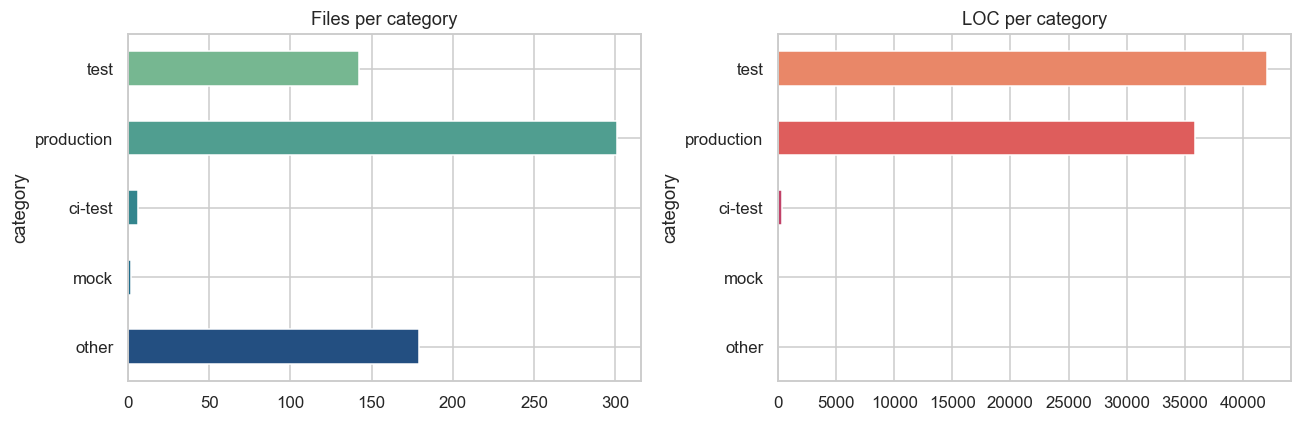

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cat_summary["files"].plot.barh(ax=axes[0], color=sns.color_palette("crest", len(cat_summary)))
axes[0].set_title("Files per category")
axes[0].invert_yaxis()

cat_summary["loc"].plot.barh(ax=axes[1], color=sns.color_palette("flare", len(cat_summary)))
axes[1].set_title("LOC per category")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [15]:
def top_module(path: str) -> str:
    parts = path.split("/")
    return parts[0] if len(parts) > 1 else "(root)"

files_df["module"] = files_df["path"].apply(top_module)
module_view = (files_df.assign(is_test=files_df["category"].isin(test_like | test_support))
               .groupby("module")
               .agg(total_files=("path", "count"),
                    test_files=("is_test", "sum"),
                    total_loc=("loc", "sum"))
               .assign(test_ratio=lambda d: d["test_files"] / d["total_files"])
               .sort_values("total_loc", ascending=False))
module_view.head(20)

,total_files,test_files,total_loc,test_ratio
module,,,,
tests,310,142,47306,0.458065
scrapy,190,0,29981,0.000000
docs,73,1,473,0.013699
.github,10,6,369,0.600000
(root),17,1,126,0.058824
extras,6,0,120,0.000000
sep,21,0,0,0.000000
tests_typing,3,0,0,0.000000


## 4. Test History (across tags/releases)

For each git tag we checkout the tree, re-run the classifier, and record how testing evolves across releases.

> ⚠️ This cell mutates the working tree (`git checkout`). It restores the original HEAD at the end. Commit or stash local changes first.

In [16]:
def list_tags_chronological(repo_path: Path):
    out = subprocess.run(
        ["git", "-C", str(repo_path), "for-each-ref",
         "--sort=creatordate",
         "--format=%(refname:short)\t%(creatordate:iso-strict)",
         "refs/tags"],
        capture_output=True, text=True, check=True,
    ).stdout.strip()
    tags = []
    for line in out.splitlines():
        if "\t" in line:
            name, date = line.split("\t", 1)
            tags.append((name, date))
    return tags

tags = list_tags_chronological(REPO_PATH)
print(f"Tags found: {len(tags)}")
for n, d in tags[-10:]:
    print(f"  {d}  {n}")

Tags found: 128
  2024-11-18T13:08:05+05:00  2.12.0
  2025-05-08T14:43:34+05:00  2.13.0
  2025-05-28T10:12:47+02:00  2.13.1
  2025-06-09T15:21:06+05:00  2.13.2
  2025-07-02T20:39:46+05:00  2.13.3
  2025-11-17T16:30:37+05:00  2.13.4
  2026-01-05T15:06:13+05:00  2.14.0
  2026-01-12T16:25:48-03:00  2.14.1
  2026-03-12T15:45:17+01:00  2.14.2
  2026-04-09T17:00:41+05:00  2.15.0


In [17]:
def current_ref(repo_path: Path) -> str:
    """Return current branch name, or commit SHA if detached."""
    r = subprocess.run(["git", "-C", str(repo_path), "symbolic-ref", "--short", "-q", "HEAD"],
                       capture_output=True, text=True)
    if r.returncode == 0 and r.stdout.strip():
        return r.stdout.strip()
    sha = subprocess.run(["git", "-C", str(repo_path), "rev-parse", "HEAD"],
                         capture_output=True, text=True, check=True).stdout.strip()
    return sha

def checkout(repo_path: Path, ref: str):
    subprocess.run(["git", "-C", str(repo_path), "checkout", "--quiet", ref], check=True)

def scan_tree(root: Path) -> dict:
    """Re-run the classifier on the current working tree."""
    counts = Counter()
    locs   = Counter()
    for rel, full in list_repo_files(root):
        cat = classify(rel)
        counts[cat] += 1
        locs[cat]   += count_lines(full) if cat != "other" else 0
    return {"counts": dict(counts), "locs": dict(locs)}

original_ref = current_ref(REPO_PATH)
print(f"Original ref: {original_ref}")

Original ref: master


In [ ]:
from tqdm.auto import tqdm

history_rows = []
CATEGORIES = ("production", "test", "e2e", "mock", "snapshot",
              "fixture", "benchmark", "smoke", "ci-test")

try:
    for name, date in tqdm(tags, desc="Scanning releases (checkout + classify)",
                           unit="tag"):
        try:
            checkout(REPO_PATH, name)
        except subprocess.CalledProcessError as e:
            print(f"  skip {name}: {e}")
            continue
        snap = scan_tree(REPO_PATH)
        row = {"tag": name, "date": date}
        for cat in CATEGORIES:
            row[f"{cat}_files"] = snap["counts"].get(cat, 0)
            row[f"{cat}_loc"]   = snap["locs"].get(cat, 0)
        history_rows.append(row)
finally:
    checkout(REPO_PATH, original_ref)
    print(f"Restored: {original_ref}")

history_df = pd.DataFrame(history_rows)
if not history_df.empty:
    history_df["date"] = pd.to_datetime(history_df["date"], utc=True)
    history_df = history_df.sort_values("date").reset_index(drop=True)
    history_df["test_to_prod_ratio"] = (
        history_df["test_loc"] / history_df["production_loc"].replace(0, pd.NA)
    )
history_df


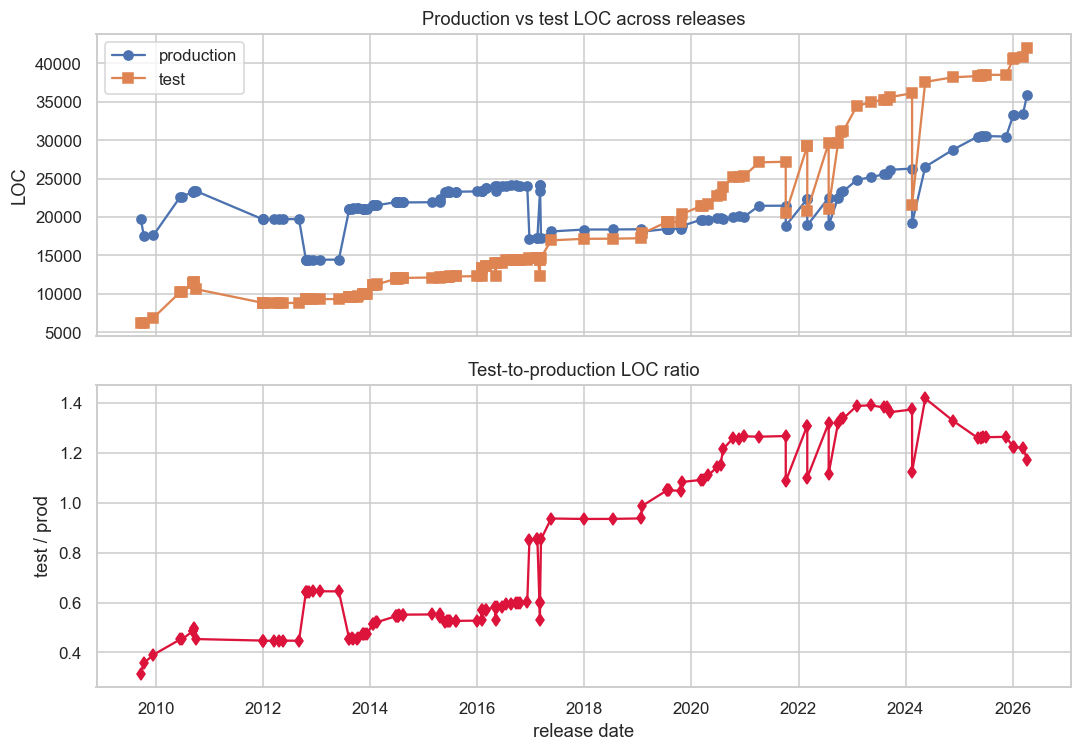

In [19]:
if history_df.empty:
    print("No tags found — test-history section is empty for this repo.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    axes[0].plot(history_df["date"], history_df["production_loc"], marker="o", label="production")
    axes[0].plot(history_df["date"], history_df["test_loc"],       marker="s", label="test")
    axes[0].set_ylabel("LOC")
    axes[0].legend()
    axes[0].set_title("Production vs test LOC across releases")

    axes[1].plot(history_df["date"], history_df["test_to_prod_ratio"],
                 marker="d", color="crimson")
    axes[1].set_ylabel("test / prod")
    axes[1].set_xlabel("release date")
    axes[1].set_title("Test-to-production LOC ratio")

    plt.tight_layout()
    plt.show()

## 5. Test Dependencies

Two views:
- **Declared** — libraries listed in `requirements*.txt`, `pyproject.toml`, `setup.py`, `Pipfile`, `package.json`
- **Imported** — actual imports found inside files classified as `test`, `e2e`, `fixture`, `mock`

Mismatch is a common smell (library installed but unused, or used but undeclared).

In [20]:
KNOWN_TEST_LIBS = {
    # python
    "pytest", "pytest-cov", "pytest-mock", "pytest-xdist", "pytest-asyncio",
    "pytest-benchmark", "pytest-django", "pytest-sugar", "pytest-bdd",
    "unittest", "nose", "nose2", "tox", "coverage", "hypothesis", "mock",
    "responses", "requests-mock", "vcrpy", "freezegun", "faker", "factory-boy",
    "testcontainers", "selenium", "playwright", "behave",
    # node
    "jest", "mocha", "chai", "jasmine", "cypress", "vitest", "ava", "tape",
    "supertest", "sinon", "enzyme", "@testing-library/react",
}

DEP_SPLIT = re.compile(r"[<>=!~;\[\s]")

def read_lines(p: Path):
    try:
        return p.read_text(encoding="utf-8", errors="ignore").splitlines()
    except Exception:
        return []

def norm_pkg(spec: str) -> str:
    return DEP_SPLIT.split(spec, 1)[0].strip().lower()

declared = set()

# requirements*.txt (skip ones inside vendored dirs)
for req in REPO_PATH.rglob("requirements*.txt"):
    if any(s in req.parts for s in SKIP_DIRS):
        continue
    for line in read_lines(req):
        line = line.strip()
        if not line or line.startswith("#") or line.startswith("-"):
            continue
        pkg = norm_pkg(line)
        if pkg:
            declared.add(pkg)

# pyproject.toml
pp = REPO_PATH / "pyproject.toml"
if pp.exists():
    try:
        import tomllib  # 3.11+
        data = tomllib.loads(pp.read_text(encoding="utf-8", errors="ignore"))
    except Exception:
        import toml
        data = toml.loads(pp.read_text(encoding="utf-8", errors="ignore"))
    proj = data.get("project", {})
    for dep in proj.get("dependencies", []) or []:
        declared.add(norm_pkg(dep))
    for _, deps in (proj.get("optional-dependencies") or {}).items():
        for dep in deps:
            declared.add(norm_pkg(dep))
    poetry = data.get("tool", {}).get("poetry", {})
    for section in ("dependencies", "dev-dependencies"):
        for k in (poetry.get(section) or {}).keys():
            declared.add(k.lower())
    for _, group in (poetry.get("group") or {}).items():
        for k in (group.get("dependencies") or {}).keys():
            declared.add(k.lower())

# package.json
pkg_json = REPO_PATH / "package.json"
if pkg_json.exists():
    try:
        pj = json.loads(pkg_json.read_text(encoding="utf-8", errors="ignore"))
        for section in ("dependencies", "devDependencies"):
            for k in (pj.get(section) or {}).keys():
                declared.add(k.lower())
    except Exception:
        pass

declared_test_libs = sorted(declared & KNOWN_TEST_LIBS)
print(f"All declared dependencies : {len(declared)}")
print(f"Of which testing-related  : {len(declared_test_libs)}")
print(declared_test_libs)

All declared dependencies : 72
Of which testing-related  : 0
[]


In [22]:
import_re = re.compile(r"^\s*(?:from\s+([\w\.]+)|import\s+([\w\.]+))", re.M)

test_paths = files_df[files_df["category"].isin(
    {"test", "e2e", "fixture", "mock", "benchmark", "smoke"}
)]["path"]

imported = Counter()
for rel in test_paths:
    full = REPO_PATH / rel
    if full.suffix != ".py":
        continue
    try:
        txt = full.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        continue
    for m in import_re.finditer(txt):
        mod = (m.group(1) or m.group(2) or "").split(".")[0].lower()
        if mod:
            imported[mod] += 1

imports_df = (pd.DataFrame(imported.most_common(), columns=["module", "occurrences"])
              .assign(is_known_test_lib=lambda d: d["module"].isin(KNOWN_TEST_LIBS),
                      declared=lambda d: d["module"].isin(declared)))
imports_df.head(25)

,module,occurrences,is_known_test_lib,declared
0,scrapy,592,False,True
1,tests,161,False,False
2,pytest,110,True,False
3,twisted,70,False,True
4,__future__,68,False,False
5,typing,59,False,False
6,unittest,32,True,False
7,pathlib,30,False,False
8,collections,25,False,False
9,warnings,25,False,False


In [23]:
imported_test = set(imports_df[imports_df["is_known_test_lib"]]["module"])
declared_test = set(declared_test_libs)

declared_not_used = sorted(declared_test - imported_test)
used_not_declared = sorted(imported_test - declared_test)

print("Declared test libs not imported anywhere:")
for x in declared_not_used:
    print(f"  - {x}")
print()
print("Test libs imported but NOT declared:")
for x in used_not_declared:
    print(f"  - {x}")

Declared test libs not imported anywhere:

Test libs imported but NOT declared:
  - pytest
  - unittest


## 6. Quality Signals

Complexity and security metrics on Python files (these tools are Python-centric).
- **radon**  — Cyclomatic Complexity (CC) + Maintainability Index (MI)
- **lizard** — language-agnostic complexity (cross-check)
- **bandit** — static security scanner

We break metrics down by **production vs test** code — the *testability* of tests themselves is a frequently overlooked signal.

In [25]:
from radon.complexity import cc_visit
from radon.metrics   import mi_visit, mi_rank

def radon_file(p: Path):
    """Return (avg_cc, max_cc, mi, n_funcs) for a python file, or None."""
    try:
        src = p.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        return None
    try:
        blocks = cc_visit(src)
        mi = mi_visit(src, multi=True)
    except Exception:
        return None
    if not blocks:
        return (0.0, 0, mi, 0)
    ccs = [b.complexity for b in blocks]
    return (sum(ccs) / len(ccs), max(ccs), mi, len(blocks))

py_files = files_df[files_df["ext"] == ".py"].copy()

metrics = []
for rel, cat in zip(py_files["path"], py_files["category"]):
    r = radon_file(REPO_PATH / rel)
    if r is None:
        continue
    avg_cc, max_cc, mi, n = r
    metrics.append({
        "path": rel, "category": cat,
        "avg_cc": avg_cc, "max_cc": max_cc,
        "mi": mi, "mi_rank": mi_rank(mi), "n_blocks": n,
    })

radon_df = pd.DataFrame(metrics)
print(f"Python files analysed by radon: {len(radon_df)}")
radon_df.head(50)

Python files analysed by radon: 445


,path,category,avg_cc,max_cc,mi,mi_rank,n_blocks
0,conftest.py,test,3.166667,10,63.163647,A,6
1,extras/qpsclient.py,production,3.000000,5,76.446288,A,5
2,extras/qps-bench-server.py,production,2.166667,4,64.176821,A,6
3,docs/conf.py,production,0.000000,0,90.251844,A,0
4,docs/conftest.py,test,1.000000,1,75.443766,A,2
5,docs/_ext/scrapydocs.py,production,1.722222,4,53.097980,A,18
6,docs/_ext/scrapyfixautodoc.py,production,1.500000,2,98.584022,A,2
7,docs/utils/linkfix.py,production,7.000000,7,83.077922,A,1
8,scrapy/responsetypes.py,production,3.777778,8,55.112609,A,9
9,scrapy/resolver.py,production,1.631579,3,69.518154,A,19


,files,avg_cc,max_cc,mi
bucket,,,,
production,301,2.04,36,76.33
test,144,2.78,28,43.13


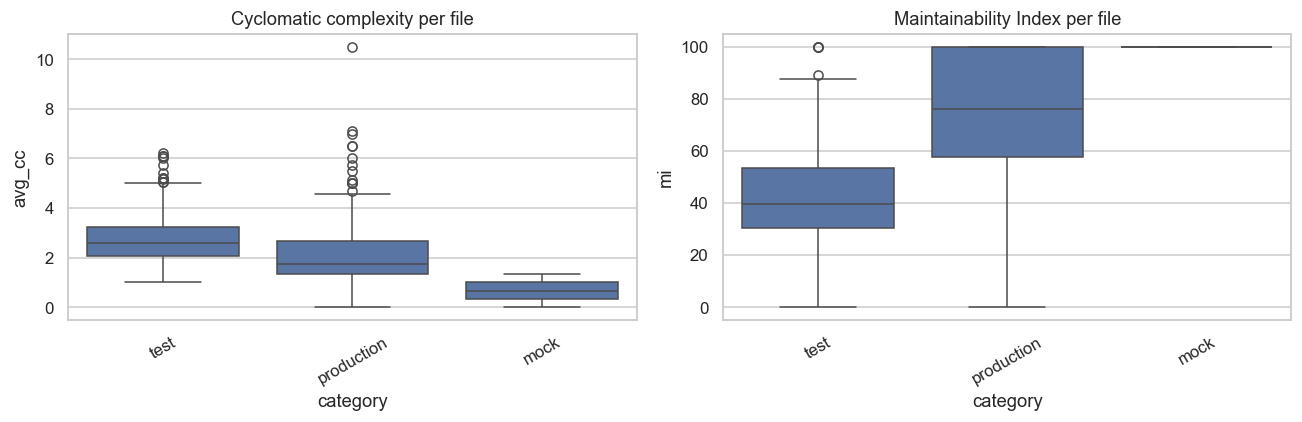

In [26]:
if radon_df.empty:
    print("No python files to analyse.")
else:
    bucket = (radon_df.assign(bucket=radon_df["category"].map(
                 lambda c: "test" if c in test_like | test_support
                           else ("production" if c == "production" else "other")))
              .groupby("bucket")
              .agg(files=("path", "count"),
                   avg_cc=("avg_cc", "mean"),
                   max_cc=("max_cc", "max"),
                   mi=("mi", "mean")))
    display(bucket.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(data=radon_df, x="category", y="avg_cc", ax=axes[0])
    axes[0].set_title("Cyclomatic complexity per file")
    axes[0].tick_params(axis="x", rotation=30)
    sns.boxplot(data=radon_df, x="category", y="mi", ax=axes[1])
    axes[1].set_title("Maintainability Index per file")
    axes[1].tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

In [27]:
# Lizard — cross-check; covers more languages
try:
    import lizard
    lz_rows = []
    for rel, full in list_repo_files(REPO_PATH):
        if Path(rel).suffix not in SOURCE_EXTS:
            continue
        try:
            res = lizard.analyze_file(str(full))
        except Exception:
            continue
        for fn in res.function_list:
            lz_rows.append({
                "path": rel,
                "category": classify(rel),
                "function": fn.name,
                "ccn": fn.cyclomatic_complexity,
                "nloc": fn.nloc,
                "tokens": fn.token_count,
                "params": len(fn.parameters),
            })
    lizard_df = pd.DataFrame(lz_rows)
    print(f"Functions analysed by lizard: {len(lizard_df)}")
    if not lizard_df.empty:
        display(lizard_df.sort_values("ccn", ascending=False).head(15))
except ImportError:
    print("lizard not installed — skipping")
    lizard_df = pd.DataFrame()

Functions analysed by lizard: 5233


,path,category,function,ccn,nloc,tokens,params
987,scrapy/core/downloader/handlers/_httpx.py,production,_read_response,19,83,449,3
877,scrapy/core/spidermw.py,production,_process_spider_output,19,75,403,4
885,scrapy/core/spidermw.py,production,_check_deprecated_start_requests_use,17,65,239,1
1716,scrapy/http/request/form.py,production,_get_inputs,16,33,212,4
1233,scrapy/downloadermiddlewares/redirect.py,production,process_response,15,39,302,4
192,scrapy/pqueues.py,production,_next_slot,15,26,156,3
206,scrapy/exporters.py,production,_get_serialized_fields,14,30,210,4
1231,scrapy/downloadermiddlewares/redirect.py,production,_build_redirect_request,14,48,274,5
866,scrapy/core/engine.py,production,close_spider_async,14,66,342,2
419,scrapy/commands/check.py,production,run,13,36,273,3


In [28]:
# Bandit — security scan (production code only)
try:
    import bandit  # noqa: F401
    prod_py = [str(REPO_PATH / p) for p in files_df[
        (files_df["category"] == "production") & (files_df["ext"] == ".py")
    ]["path"]]

    if not prod_py:
        print("No production python files for bandit.")
        bandit_findings = []
    else:
        r = subprocess.run(
            ["bandit", "-q", "-f", "json", "--severity-level", "low"] + prod_py,
            capture_output=True, text=True,
        )
        try:
            bandit_out = json.loads(r.stdout)
            bandit_findings = bandit_out.get("results", [])
        except json.JSONDecodeError:
            print("bandit produced non-JSON output:")
            print(r.stderr[:500])
            bandit_findings = []

    print(f"Bandit findings: {len(bandit_findings)}")
    if bandit_findings:
        bdf = pd.DataFrame([{
            "severity":   f.get("issue_severity"),
            "confidence": f.get("issue_confidence"),
            "test_id":    f.get("test_id"),
            "issue":      f.get("issue_text"),
            "file":       os.path.relpath(f.get("filename", ""), REPO_PATH),
            "line":       f.get("line_number"),
        } for f in bandit_findings])
        display(bdf.groupby(["severity", "confidence"]).size().unstack(fill_value=0))
        display(bdf.head(15))
    else:
        bdf = pd.DataFrame()
except ImportError:
    print("bandit not installed — skipping")
    bandit_findings = []
    bdf = pd.DataFrame()

Bandit findings: 493


confidence,HIGH,MEDIUM
severity,,
HIGH,17,0
LOW,468,1
MEDIUM,5,2


,severity,confidence,test_id,issue,file,line
0,LOW,HIGH,B101,Use of assert detected. The enclosed code will...,scrapy/commands/__init__.py,81
1,LOW,HIGH,B101,Use of assert detected. The enclosed code will...,scrapy/commands/__init__.py,114
2,LOW,HIGH,B101,Use of assert detected. The enclosed code will...,scrapy/commands/__init__.py,190
3,LOW,HIGH,B404,Consider possible security implications associ...,scrapy/commands/bench.py,3
4,LOW,HIGH,B101,Use of assert detected. The enclosed code will...,scrapy/commands/bench.py,32
5,LOW,HIGH,B603,subprocess call - check for execution of untru...,scrapy/commands/bench.py,40
6,LOW,HIGH,B101,Use of assert detected. The enclosed code will...,scrapy/commands/bench.py,43
7,LOW,HIGH,B101,Use of assert detected. The enclosed code will...,scrapy/commands/bench.py,67
8,LOW,HIGH,B101,Use of assert detected. The enclosed code will...,scrapy/commands/check.py,75
9,LOW,HIGH,B101,Use of assert detected. The enclosed code will...,scrapy/commands/check.py,84


## 7. X-Ray Summary

A one-page, opinionated score. It is **heuristic** — useful as a quick smell-check, not a certification.

In [29]:
def score(value, thresholds, reverse=False):
    """thresholds = (good, ok); reverse=True when lower is better."""
    good, ok = thresholds
    if reverse:
        if value <= good: return ("🟢 good",  2)
        if value <= ok:   return ("🟡 ok",    1)
        return ("🔴 poor", 0)
    else:
        if value >= good: return ("🟢 good",  2)
        if value >= ok:   return ("🟡 ok",    1)
        return ("🔴 poor", 0)

# Inputs
test_ratio      = ratio
avg_prod_cc     = radon_df[radon_df["category"] == "production"]["avg_cc"].mean() if not radon_df.empty else 0
avg_prod_mi     = radon_df[radon_df["category"] == "production"]["mi"].mean()     if not radon_df.empty else 0
ci_present      = int((files_df["category"] == "ci-test").sum() > 0)
bandit_high     = int(sum(1 for f in bandit_findings if f.get("issue_severity") == "HIGH"))
testing_libs_n  = len(declared_test_libs)

checks = [
    ("Test / Production LOC ratio", f"{test_ratio:.0%}",          *score(test_ratio, (0.50, 0.20))),
    ("Production avg CC",           f"{avg_prod_cc:.2f}",         *score(avg_prod_cc, (3.0, 6.0), reverse=True)),
    ("Production avg MI",           f"{avg_prod_mi:.1f}",         *score(avg_prod_mi, (70, 50))),
    ("CI config present",           "yes" if ci_present else "no", *score(ci_present, (1, 1))),
    ("Declared testing libs",       str(testing_libs_n),          *score(testing_libs_n, (3, 1))),
    ("Bandit HIGH findings",        str(bandit_high),             *score(bandit_high, (0, 2), reverse=True)),
]

summary_df = pd.DataFrame(
    [(name, val, verdict) for name, val, verdict, _ in checks],
    columns=["metric", "value", "verdict"],
)
pts   = sum(s for *_, s in checks)
total = 2 * len(checks)
overall_verdict = ("🟢 healthy"    if pts / total >= 0.75
                   else "🟡 acceptable" if pts / total >= 0.5
                   else "🔴 needs work")
summary_df.loc[len(summary_df)] = ["OVERALL", f"{pts}/{total}", overall_verdict]
summary_df

,metric,value,verdict
0,Test / Production LOC ratio,117%,🟢 good
1,Production avg CC,2.04,🟢 good
2,Production avg MI,76.3,🟢 good
3,CI config present,yes,🟢 good
4,Declared testing libs,0,🔴 poor
5,Bandit HIGH findings,17,🔴 poor
6,OVERALL,8/12,🟡 acceptable


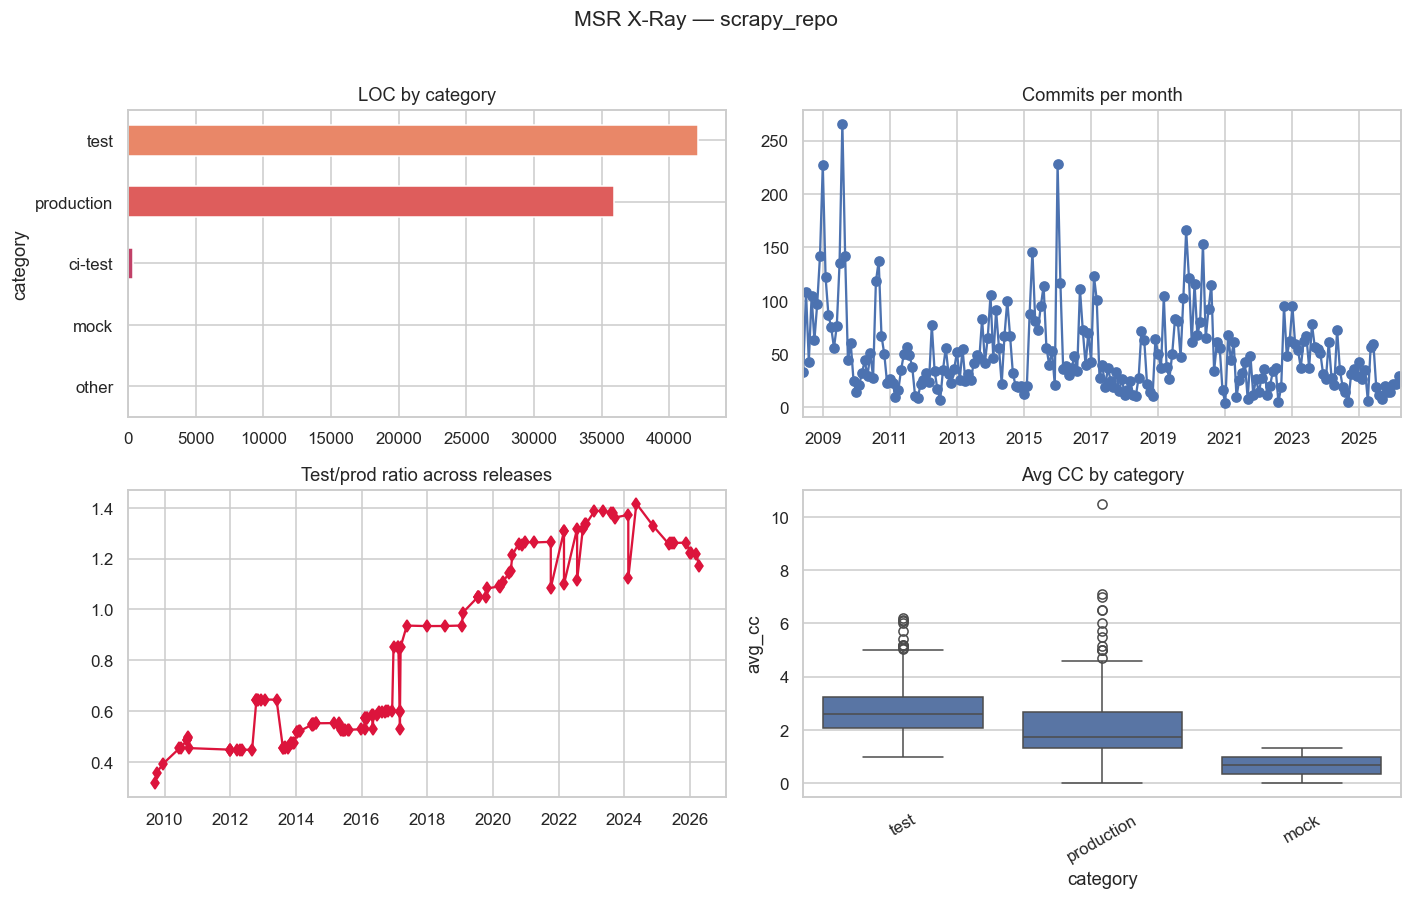

In [30]:
# One-page dashboard
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# (1) category LOC
cat_summary["loc"].plot.barh(ax=axes[0, 0], color=sns.color_palette("flare", len(cat_summary)))
axes[0, 0].set_title("LOC by category")
axes[0, 0].invert_yaxis()

# (2) commits over time
if not monthly.empty:
    monthly.plot(ax=axes[0, 1], marker="o")
    axes[0, 1].set_title("Commits per month")
    axes[0, 1].set_xlabel("")
else:
    axes[0, 1].text(0.5, 0.5, "no commit history", ha="center", va="center",
                    transform=axes[0, 1].transAxes)
    axes[0, 1].set_title("Commits per month")

# (3) test/prod ratio over releases
if not history_df.empty:
    axes[1, 0].plot(history_df["date"], history_df["test_to_prod_ratio"],
                    marker="d", color="crimson")
    axes[1, 0].set_title("Test/prod ratio across releases")
else:
    axes[1, 0].text(0.5, 0.5, "no tags", ha="center", va="center",
                    transform=axes[1, 0].transAxes)
    axes[1, 0].set_title("Test/prod ratio across releases")

# (4) complexity distribution
if not radon_df.empty:
    sns.boxplot(data=radon_df, x="category", y="avg_cc", ax=axes[1, 1])
    axes[1, 1].tick_params(axis="x", rotation=30)
    axes[1, 1].set_title("Avg CC by category")
else:
    axes[1, 1].axis("off")

fig.suptitle(f"MSR X-Ray — {REPO_PATH.name}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Extended Testing Metrics

Beyond LOC ratios and cyclomatic complexity, modern test-suite research (Petrović et al., Just et al., ISO/IEC 25010:2023) converges on a small set of higher-signal metrics:

| Metric | What it captures | Why it matters |
|---|---|---|
| **Assertion density** | assertions per test LOC | tests that execute code without asserting are *false coverage* |
| **Test pyramid shape** | unit ∶ integration ∶ e2e | inverted pyramids are slow and flaky |
| **Complexity × churn** | CC-weighted change hot-spots | highest-risk files to cover first |
| **Co-change coupling** | shared commits between test ↔ prod | 'touched together' implies traceability |
| **BDD / scenario footprint** | `.feature` files, Given/When/Then counts | maps user-story coverage to executable specs |
| **Skip / flake markers** | `@skip`, `.skip(`, `xit(`, `@Ignore` | reliability debt |
| **Testability composite (ISO/IEC 25010)** | weighted score of MI, CC, assertion density | approximates the maintainability sub-characteristic 'testability' |

> **References**
> - ISO/IEC 25010:2023 — *Systems and software quality models* (product quality characteristics including testability). [iso.org](https://www.iso.org/standard/78176.html)
> - Petrović, G. et al. — *Test suite effectiveness metric evaluation*. [arXiv:2204.09165](https://arxiv.org/abs/2204.09165)
> - Wikipedia — [Mutation testing](https://en.wikipedia.org/wiki/Mutation_testing), [Behavior-driven development](https://en.wikipedia.org/wiki/Behavior-driven_development)

The cells below compute each of these for the current repository and plot them with `seaborn`, `plotly`, `networkx`, and `squarify`. Sections marked **YOUR INPUT** contain a short design choice for you to make — a decision that genuinely shapes the result.

### 8.1 Assertion density

A test file that imports `pytest` and calls functions but never asserts will still show up as 100 % line-covered and 0 % useful.

**Heuristic:** count distinct assertion tokens per test file. We cover the main five languages this classifier targets. The metric is `assertions / test_LOC`.

In [ ]:
ASSERTION_PATTERNS = {
    ".py":   re.compile(r"\b(assert\b|pytest\.raises|self\.assert\w+)"),
    ".js":   re.compile(r"\b(expect\(|assert\.|should\.|chai\.assert|chai\.expect)"),
    ".jsx":  re.compile(r"\b(expect\(|assert\.|should\.)"),
    ".ts":   re.compile(r"\b(expect\(|assert\.|should\.)"),
    ".tsx":  re.compile(r"\b(expect\(|assert\.|should\.)"),
    ".java": re.compile(r"\b(Assert\.|assertThat|assertEquals|assertTrue|assertFalse|assertNull|assertNotNull)"),
    ".rb":   re.compile(r"\b(assert[_\w]*|expect\(|should\b)"),
    ".go":   re.compile(r"\b(t\.(?:Error|Errorf|Fatal|Fatalf|FailNow)|assert\.)"),
}

def count_assertions(path: Path, ext: str) -> int:
    pat = ASSERTION_PATTERNS.get(ext)
    if pat is None:
        return 0
    try:
        txt = path.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        return 0
    return sum(1 for _ in pat.finditer(txt))

test_files_df = files_df[files_df["category"].isin(test_like)].copy()
if test_files_df.empty:
    print("No test files found — skipping assertion density.")
    assertions_df = pd.DataFrame()
else:
    test_files_df["assertions"] = [
        count_assertions(REPO_PATH / p, e)
        for p, e in zip(test_files_df["path"], test_files_df["ext"])
    ]
    test_files_df["density"] = test_files_df["assertions"] / test_files_df["loc"].replace(0, pd.NA)
    assertions_df = test_files_df[["path", "category", "ext", "loc", "assertions", "density"]]
    print(f"Assertions total: {int(assertions_df['assertions'].sum()):,}")
    print(f"Tests with zero assertions: {(assertions_df['assertions'] == 0).sum()} / {len(assertions_df)}")
    display(assertions_df.sort_values("density", ascending=False).head(10))


In [ ]:
if assertions_df.empty:
    print("No assertion data to plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.violinplot(data=assertions_df, x="category", y="density",
                   inner="quartile", cut=0, ax=axes[0])
    axes[0].set_title("Assertion density (assertions / LOC) by category")
    axes[0].set_ylabel("density")

    zero_share = (assertions_df.assign(empty=assertions_df["assertions"] == 0)
                  .groupby("category")["empty"].mean().sort_values(ascending=False))
    zero_share.plot.barh(ax=axes[1], color=sns.color_palette("rocket", len(zero_share)))
    axes[1].set_title("Share of test files with ZERO assertions")
    axes[1].set_xlim(0, 1)
    axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    plt.tight_layout()
    plt.show()


### 8.2 Test pyramid shape

The classical test-pyramid prescribes **many unit → fewer integration → very few e2e** tests. An inverted shape (lots of e2e, no units) signals slow, flaky suites with bad diagnosability.

In [ ]:
import plotly.graph_objects as go

pyramid_buckets = {
    "unit":        ["test"],
    "integration": ["e2e"],
    "smoke/bench": ["smoke", "benchmark"],
    "support":     ["mock", "fixture", "snapshot", "ci-test"],
}

pyramid = {}
for bucket, cats in pyramid_buckets.items():
    sel = files_df[files_df["category"].isin(cats)]
    pyramid[bucket] = {"files": len(sel), "loc": int(sel["loc"].sum())}

pyr_df = pd.DataFrame(pyramid).T
display(pyr_df)

fig = go.Figure(go.Funnel(
    y=list(pyramid.keys()),
    x=[v["loc"] for v in pyramid.values()],
    textinfo="value+percent initial",
    marker={"color": ["#2ca02c", "#ffbf00", "#ff7f0e", "#d62728"]},
))
fig.update_layout(title="Test pyramid (LOC) — bottom should be widest",
                  height=420, margin=dict(l=40, r=40, t=60, b=40))
fig.show()


### 8.3 Complexity × churn — where the risk lives

For each **production** file, we plot `avg_cc` against `churn`. Bubble size = LOC. Colour tells us whether a same-named test exists. Files top-right with no matching test are the highest-leverage places to add coverage first.

In [ ]:
def has_matching_test(prod_path: str, test_paths: set) -> bool:
    stem = Path(prod_path).stem.lower()
    return any(stem in tp.lower() for tp in test_paths)

test_path_set = set(files_df[files_df["category"].isin(test_like)]["path"])

if radon_df.empty or churn_df.empty:
    print("radon_df or churn_df missing — skipping bubble plot.")
else:
    prod = (radon_df[radon_df["category"] == "production"]
            .merge(churn_df, on="path", how="left")
            .fillna({"churn": 0, "touches": 0}))
    prod["loc"] = prod["path"].map(files_df.set_index("path")["loc"]).fillna(0)
    prod["has_test"] = prod["path"].apply(lambda p: has_matching_test(p, test_path_set))

    fig, ax = plt.subplots(figsize=(11, 6))
    sns.scatterplot(
        data=prod, x="churn", y="avg_cc",
        size="loc", sizes=(20, 600),
        hue="has_test", palette={True: "#2ca02c", False: "#d62728"},
        alpha=0.7, ax=ax, legend="brief",
    )
    ax.set_xscale("symlog")
    ax.set_title("Production files — churn vs. cyclomatic complexity (green = has matching test)")
    ax.set_xlabel("churn (lines added + deleted, symlog)")
    ax.set_ylabel("avg cyclomatic complexity")

    hot = prod.nlargest(5, "avg_cc").query("has_test == False")
    for _, r in hot.iterrows():
        ax.annotate(r["path"], (r["churn"], r["avg_cc"]),
                    fontsize=8, xytext=(5, 5), textcoords="offset points")
    plt.tight_layout()
    plt.show()


### 8.4 Test ↔ production co-change network

When a production file and a test file appear in the *same commit* repeatedly, that's strong evidence of a traceability link. We walk up to the last 300 commits, build a bipartite graph between test and production files, and render the dense core.

In [ ]:
import networkx as nx

MAX_COMMITS      = 300
MIN_CO_CHANGES   = 2

pairs = Counter()
touched_prod = Counter()
touched_test = Counter()

for i, commit in enumerate(Repository(str(REPO_PATH)).traverse_commits()):
    if i >= MAX_COMMITS:
        break
    prods, tests = [], []
    for mf in commit.modified_files:
        p = mf.new_path or mf.old_path
        if not p:
            continue
        cat = classify(p)
        if cat == "production":
            prods.append(p); touched_prod[p] += 1
        elif cat in test_like:
            tests.append(p); touched_test[p] += 1
    for a in prods:
        for b in tests:
            pairs[(a, b)] += 1

print(f"Bipartite pairs observed: {len(pairs)} (thresholded at ≥{MIN_CO_CHANGES})")

G = nx.Graph()
for (prod, test), w in pairs.items():
    if w >= MIN_CO_CHANGES:
        G.add_edge(prod, test, weight=w)

if G.number_of_edges() == 0:
    print("No co-change pairs meet threshold — try lowering MIN_CO_CHANGES.")
else:
    top_nodes = sorted(G.nodes, key=lambda n: G.degree(n, weight="weight"), reverse=True)[:25]
    H = G.subgraph(top_nodes)
    colors = ["#1f77b4" if classify(n) == "production" else "#ff7f0e" for n in H.nodes]
    sizes  = [300 + 40 * (touched_prod.get(n, 0) + touched_test.get(n, 0)) for n in H.nodes]

    fig, ax = plt.subplots(figsize=(12, 8))
    pos = nx.spring_layout(H, seed=42, k=0.7)
    nx.draw_networkx_edges(H, pos, alpha=0.3, width=[H[u][v]["weight"] for u, v in H.edges], ax=ax)
    nx.draw_networkx_nodes(H, pos, node_color=colors, node_size=sizes, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(H, pos, font_size=8,
                             labels={n: Path(n).name for n in H.nodes}, ax=ax)
    ax.set_title(f"Top {len(H.nodes)} co-change nodes (blue=prod, orange=test, edge=# shared commits)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


### 8.5 LOC treemap

Squarify's treemap makes the *proportional weight* of each category impossible to misread — bar charts tend to flatten the eye's perception of ratios.

In [ ]:
import squarify

if cat_summary.empty:
    print("no categories to render")
else:
    sizes  = cat_summary["loc"].values
    labels = [f"{c}\n{l:,} LOC" for c, l in zip(cat_summary.index, sizes)]
    colors = sns.color_palette("viridis", len(sizes))

    fig, ax = plt.subplots(figsize=(11, 6))
    squarify.plot(sizes=sizes, label=labels, color=colors,
                  alpha=0.85, pad=True, text_kwargs={"fontsize": 10, "color": "white"},
                  ax=ax)
    ax.set_title(f"Codebase composition — LOC treemap ({REPO_PATH.name})")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


### 8.6 BDD / Gherkin footprint — **YOUR INPUT**

If the repo has any `.feature` files (Cucumber / Behave / SpecFlow / pytest-bdd), this cell counts scenarios and Given/When/Then steps.

**Design decision for you:** define what counts as a *well-formed* scenario. A common rule is 'at least one `Given` and one `Then`,' but some teams require all three keywords, and BDD-purists require a **single** `When`. See the `is_well_formed()` stub below — pick your rule and implement it in ~5 lines. Your choice directly influences the 'quality' count on the bar chart.

In [ ]:
GHERKIN_KEYWORDS = {
    "en": {"Given", "When", "Then", "And", "But", "Background", "Scenario"},
    "pt": {"Dado", "Quando", "Então", "E", "Mas", "Contexto", "Cenário"},  # Gherkin-pt
}
FLAT_STEP_KWS = {k for langs in GHERKIN_KEYWORDS.values() for k in langs
                 if k not in {"Background", "Scenario", "Contexto", "Cenário"}}
SCENARIO_KWS  = {"Scenario", "Cenário"}

def parse_feature(path: Path) -> dict:
    try:
        lines = path.read_text(encoding="utf-8", errors="ignore").splitlines()
    except Exception:
        return {"scenarios": [], "steps": Counter()}
    scenarios, current = [], None
    for line in lines:
        s = line.strip()
        head = s.split(":", 1)[0].strip() if ":" in s else s.split(None, 1)[0] if s else ""
        if head in SCENARIO_KWS:
            if current is not None:
                scenarios.append(current)
            current = Counter()
        elif current is not None:
            kw = s.split(None, 1)[0] if s else ""
            if kw in FLAT_STEP_KWS:
                current[kw] += 1
    if current is not None:
        scenarios.append(current)
    total_steps = Counter()
    for sc in scenarios:
        total_steps.update(sc)
    return {"scenarios": scenarios, "steps": total_steps}

# --- YOUR INPUT -----------------------------------------------------------
def is_well_formed(scenario_counter: Counter) -> bool:
    """Return True if this scenario counts as 'well-formed' per your rule.
    Approaches to consider:
      A. Needs >=1 Given and >=1 Then       (loose / common)
      B. Needs >=1 Given, >=1 When, >=1 Then (strict three-part)
      C. Needs exactly one When             (BDD purist)
    The cell below uses this function to plot 'quality' vs 'total'.
    """
    # TODO (5-ish lines): pick one of A/B/C (or define your own) and implement.
    # Remember both English and Portuguese Gherkin keywords exist in the counter.
    raise NotImplementedError("define your well-formedness rule for BDD scenarios")
# --------------------------------------------------------------------------

feature_files = [p for p, _ in list_repo_files(REPO_PATH) if p.endswith(".feature")]
print(f".feature files found: {len(feature_files)}")

if not feature_files:
    print("No Gherkin files in this repo — skipping BDD footprint.")
    bdd_df = pd.DataFrame()
else:
    rows = []
    for rel in feature_files:
        parsed = parse_feature(REPO_PATH / rel)
        try:
            ok = sum(1 for sc in parsed["scenarios"] if is_well_formed(sc))
        except NotImplementedError:
            ok = 0
        rows.append({
            "feature":   rel,
            "scenarios": len(parsed["scenarios"]),
            "well_formed": ok,
            **dict(parsed["steps"]),
        })
    bdd_df = pd.DataFrame(rows).fillna(0)
    display(bdd_df)

    fig, ax = plt.subplots(figsize=(11, max(3, 0.4 * len(bdd_df))))
    bdd_df.set_index("feature")[["scenarios", "well_formed"]].plot.barh(ax=ax)
    ax.set_title("Scenarios per .feature file (orange = well-formed by your rule)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


### 8.7 Skip / ignore markers — flake & reliability debt

Flaky tests eventually get skipped, and skipped tests are invisible failures. We grep for skip / ignore markers across the main test frameworks.

In [ ]:
SKIP_PATTERNS = {
    "pytest":      re.compile(r"@pytest\.mark\.(skip|skipif|xfail)"),
    "unittest":    re.compile(r"@unittest\.(skip|skipIf|skipUnless|expectedFailure)"),
    "jest/mocha":  re.compile(r"\b(xit|xdescribe|it\.skip|describe\.skip|test\.skip)\("),
    "junit4":      re.compile(r"@Ignore\b"),
    "junit5":      re.compile(r"@Disabled\b"),
    "rspec":       re.compile(r"\b(xit|skip)\s"),
    "go-test":     re.compile(r"\bt\.Skip(Now|f)?\("),
}

skip_rows = []
it = test_files_df["path"] if not test_files_df.empty else []
for rel in it:
    full = REPO_PATH / rel
    try:
        txt = full.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        continue
    for framework, pat in SKIP_PATTERNS.items():
        n = len(pat.findall(txt))
        if n:
            skip_rows.append({"path": rel, "framework": framework, "count": n})

skip_df = pd.DataFrame(skip_rows)
if skip_df.empty:
    print("No skip/ignore markers found.")
else:
    print(f"Skipped-test markers: {int(skip_df['count'].sum())} across {skip_df['path'].nunique()} files")
    display(skip_df.groupby("framework")["count"].sum().sort_values(ascending=False))
    fig, ax = plt.subplots(figsize=(9, 3.5))
    (skip_df.groupby("framework")["count"].sum()
      .sort_values().plot.barh(ax=ax, color=sns.color_palette("rocket_r", skip_df["framework"].nunique())))
    ax.set_title("Skip / ignore markers by framework (lower is better)")
    plt.tight_layout()
    plt.show()


### 8.8 ISO/IEC 25010 testability radar — **YOUR INPUT**

A composite 'testability' proxy inspired by ISO/IEC 25010:2023's *maintainability → testability* sub-characteristic. We combine five normalised (0–1) signals:

1. `mi_norm` — mean Maintainability Index / 100
2. `cc_inv`  — `1 − min(avg_cc / 10, 1)` (lower CC is better)
3. `density_norm` — mean assertion density clamped to [0, 1]
4. `test_ratio_norm` — `min(test_loc / prod_loc, 1)`
5. `no_skip_norm` — `1 − min(skips / tests, 1)` (fewer skips is better)

**Design decision for you:** choose the **weights** that combine these into one score. Weights sum to 1. See the `WEIGHTS` dict below — pick values that reflect what *you* think matters most for a 'testable' codebase.

In [ ]:
# --- YOUR INPUT -----------------------------------------------------------
# Assign 5 numbers that sum to 1.0. The chart will recompute the composite.
WEIGHTS = {
    "mi_norm":         0.20,   # maintainability
    "cc_inv":          0.20,   # low cyclomatic complexity
    "density_norm":    0.25,   # assertions per test LOC
    "test_ratio_norm": 0.25,   # test / prod LOC coverage proxy
    "no_skip_norm":    0.10,   # penalise skipped tests
}
# TODO: tweak the five numbers above so they sum to 1.0 and reflect YOUR priorities.
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-6, f"weights must sum to 1.0, got {sum(WEIGHTS.values())}"
# --------------------------------------------------------------------------

def clamp01(x):
    if pd.isna(x): return 0.0
    return max(0.0, min(1.0, float(x)))

prod_rows = radon_df[radon_df["category"] == "production"] if not radon_df.empty else pd.DataFrame()

signals = {
    "mi_norm":         clamp01((prod_rows["mi"].mean() if not prod_rows.empty else 0) / 100),
    "cc_inv":          clamp01(1 - ((prod_rows["avg_cc"].mean() if not prod_rows.empty else 0) / 10)),
    "density_norm":    clamp01(assertions_df["density"].mean() if not assertions_df.empty else 0),
    "test_ratio_norm": clamp01(ratio),
    "no_skip_norm":    clamp01(1 - (
        (skip_df["count"].sum() / max(len(assertions_df), 1))
        if not skip_df.empty and not assertions_df.empty else 0
    )),
}

composite = sum(signals[k] * WEIGHTS[k] for k in WEIGHTS)
print(f"Testability composite: {composite:.2f} / 1.00")
display(pd.Series(signals).to_frame("value").assign(weight=pd.Series(WEIGHTS)))

import numpy as np
labels = list(signals.keys())
values = [signals[k] for k in labels]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
values += values[:1]; angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, values, linewidth=2, color="#1f77b4")
ax.fill(angles, values, alpha=0.25, color="#1f77b4")
ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title(f"ISO/IEC 25010 testability radar — composite = {composite:.2f}", pad=20)
plt.tight_layout()
plt.show()


### Reading the extended metrics together

- A **green dashboard (Section 7) + low assertion density (8.1)** is the classic 'false-confidence' signal — tests run but don't verify.
- **Inverted pyramid (8.2) + dense co-change network (8.4)** usually means brittle e2e tests are the only traceability link you have; add unit tests for the hotspots surfaced in 8.3.
- **High skip count (8.7) + low testability composite (8.8)** is reliability debt — prioritise fixing flaky tests before writing new ones.
- The **BDD footprint (8.6)** only fires if the repo is behaviour-driven; absence is not a failure, but presence with many *ill-formed* scenarios indicates Gherkin-as-theatre.

---

### What to do with this

- **Low test/prod ratio** → invest in writing tests where churn is high (cross-reference `churn_df` with production files that have few matching tests).
- **High CC in production** → candidates for refactoring; pair with the churn list to prioritise refactors that will keep paying off.
- **Declared-but-unused test libs** → dead dependencies, prune them.
- **Imported-but-undeclared** → add to `pyproject.toml` / `requirements` to make the build reproducible.
- **Bandit HIGH severity** → triage before next release.
- **No tags** → adopt semantic versioning so test-history analysis becomes possible.

### Extending

- Add more classifiers (Go's `_test.go`, Rust's `#[cfg(test)]`, Java's `src/test/`).
- Swap radon for `cohesion` / `wily` to trend complexity per commit.
- Export `files_df`, `commits_df`, `history_df`, `radon_df` to parquet and wire them into Grafana/Streamlit for a live dashboard.